### Libraries

In [1]:
#using BenchmarkTools
using LinearAlgebra          ### Linear algebra library
using PyPlot
#using Plots                  ### Library to make plots
#using DifferentialEquations  ### Library to use differential equations
#using Tullio                 ### Library to work with tensors
#using Base.Threads           ### Function to check the number of threads 
#using DelimitedFiles         ### Manipulate files 
#using LaTeXStrings           ### Latex strings
using StaticArrays
#using Serialization
n_threads = Threads.nthreads() ##= 4
println("Number of threads used in operations is : " , n_threads )
⊗(A,B) = kron(A,B)

Number of threads used in operations is : 1


⊗ (generic function with 1 method)

### Parameters


In [2]:
#vm_ijx = zeros(Float64,nx,ny,3)
σ_0 = Matrix{ComplexF64}([1. 0. ; 0 1]) 
σ_x =  Matrix{ComplexF64}([0 1; 1 0]) 
σ_y =  Matrix{ComplexF64}([0 -im ; im 0 ])
σ_z = Matrix{ComplexF64}([1 0. ; 0. -1])

2×2 Matrix{ComplexF64}:
 1.0+0.0im   0.0+0.0im
 0.0+0.0im  -1.0+0.0im

### Auxiliary functions 

In [3]:
### Pulse of light 
# function A_light(gv; )
#     "This function returns a pulse of the light"
#     ts=0.0:gv.t_step:gv.t_end
#     return gv.A_max*exp.(-((ts.-gv.t_p).^2)/(2*gv.sigma^2)).*sin.(gv.Omega_0*ts)
# end

### Hamiltonian 

In [4]:
######## Particular of the model 
### General Hamiltonian for an square lattice 
### Block Hamiltonian 
# function block_h(;vm_ijx::Array{Float64,2},ny::Int,nσ::Int,γ::Float64,γso::Float64) #(gv,cv)
#     #γ::Float64,γso::ComplexF64,Bz::Float64,ny::Int)
#     "Creates the building blocks for a general nx x ny square lattice "
#     dim = ny*nσ # We include the spin degree of freedom 
#     ######
#     H0 = zeros(ComplexF64,dim,dim)
#     T  = zeros(ComplexF64,dim,dim)
#     One_y = Diagonal(ones(ny))
#     ######
#     Ty = diagm(-1 =>  ones(ny-1))
#     T0 = Ty⊗(-γ*σ_0 - 1im*γso*σ_x)
#     H0 .= T0 + T0' #-Bz*kron(One_y, σ_z)
#     ######
#     T .= One_y⊗(-γ*σ_0 + γso*1im*σ_y)
#     H0 += m_x⊗σ_x + m_y⊗σ_y + m_z⊗σ_z
#     return H0, T
# end
function Block_H(γ,γso,Bz,ny)
    dim = ny*2 # We include the spin degree of freedom 
    H0 = zeros(ComplexF64,dim,dim)
    T  = zeros(ComplexF64,dim,dim)
    One_y = Diagonal(ones(ny))
    ######
    Ty = diagm(-1 =>  ones(ny-1))
    T0 = Ty⊗(-γ*σ_0 - 1im*γso*σ_x)
    H0 .= T0 + T0' -Bz*kron(One_y, σ_z)
    ######
    T .= One_y⊗(-γ*σ_0 + γso*1im*σ_y)
    return H0, T
end
### Central Hamiltonian
function hs(vm_i1x::Array{Float64,2};nx::Int,ny::Int,γ::Float64,γso::Float64,j_sd::Float64)
    "This function build the central hamiltonian wwith two band"
    #γ::Float64,γso::ComplexF64,Bz::Float64,nx::Int,ny::Int)
    dim = nx*ny*2 #*2
    zero = zeros(ComplexF64,nx,nx)
    HC = zeros(ComplexF64,dim,dim)
    One_x = Diagonal(ones(nx))
    H0,T = block_h(;ny,γ,γso)
    Tx = diagm( -1 =>  ones(nx-1))⊗T 
    HC = (One_x⊗H0) +  Tx + Tx'
    ### Local moments
    for i in range(1,nx) 
        zero[i,i] = 1.0
        HC += -j_sd*zero⊗(vm_i1x[i,1]*σ_x
                    +vm_i1x[i,2]*σ_y
                    +vm_i1x[i,3]*σ_z)
        zero[i,i] = 0.0
    end
    return HC
end

hs (generic function with 1 method)

### Self energy

In [9]:
function Σ_LS(ϵ;H0l,H1l,Hlc,η, err=1e-8)
    "Calculation of the selfenergy. 
    The parameters needed are
    H0L : Supercell
    HLC: Matrix connecting the central system with the leads
    H1L : Hopping between super cells "
    one = I(size(H0l)[1])
    #Diagonal(ones(size(H0l)[1]))
    A0 = H1l'
    B0 = H1l
    C0 = (ϵ + 1im*η)*one - H0l
    D0 = (ϵ +1im*η)*one - H0l
    invD0 = inv(D0)
    while norm(A0) > err
        C = C0 - A0*invD0*B0
        D = D0 - A0*invD0*B0 - B0*invD0*A0
        A = A0*invD0*A0
        B = B0*invD0*B0
        ###################################
        A0 = A
        B0 = B
        C0 = C
        D0 = D
        invD0 =inv(D0)
    end
    g_L = inv(C0) ### Surface green function of the lead 
    Self = Hlc'*g_L*Hlc
end
#### Calculation of the self-energy for 1d system 
function Σ_1d(ϵ::ComplexF64; γ::Float64=1. ,γc::Float64=1.)
    Δ = 4 * γ^2 - ϵ^2
    if real(Δ) > 0
        Σ = ϵ - im * sqrt(Δ)
    else
        if real(ϵ) > 0
            sgn = 1
        else
            sgn = -1
        end
        Σ = ϵ - sgn * sqrt(-Δ)
    end
    Σ = Σ* (γc^2 / (2 * γ^2))
    return Σ
end


# function Σ_1d(ϵ::ComplexF64; γ::Float64=1. ,γc::Float64=1.)
#     Δ = 4 * γ^2 - ϵ^2
#     if real(Δ) > 0
#         Σ = ϵ - im * sqrt(Δ)
#     else
#         if real(ϵ) > 0
#             sgn = 1
#         else
#             sgn = -1
#         end
#         Σ = ϵ - sgn * sqrt(-Δ)
#     end
#     Σ = Σ* (γc^2 / (2 * γ^2))
#     return Σ
# end

Σ_1d (generic function with 1 method)

In [40]:
function gr_n(ϵ;n,γ=1.,γc=1.,Ny=5)
    """ Retarded GF in the diagonal transverse basis chanel 
    """
    ϵ_n = -2*γ*cos(n*pi/(Ny+1))
    Δ = 4 * γ^2 - (ϵ - ϵ_n)^2
    if real(Δ) > 0
        Σ = ϵ - ϵ_n - im*sqrt(Δ)
    else
        if real(ϵ - ϵ_n) > 0
            sgn = 1
        else
            sgn = -1
        end
        Σ  = ϵ-ϵ_n - sgn * sqrt(-Δ)
    end
    Σ = Σ* (γc^2 / (2 * γ^2))
    return Σ
end
#### Components of the Gamma function 
function Γ_ij(ϵ;i,j,γ=1.,γc=1.,Ny=5)
    """ Components of the Gamma function in the lattice basis
    """
    Γ(ϵ,n) = -2*imag(gr_n(ϵ;n=n,γ=γ,γc=γc,Ny=Ny))
    U_in(i,n) = sin(n*i*pi/(Ny+1))*sqrt(2/(Ny+1))
    res = 0.0
    for n_s in 1:Ny
        res += U_in(i,n_s)*Γ(ϵ,n_s)*U_in(j,n_s)
    end
    return res
end


Γ_ij (generic function with 1 method)

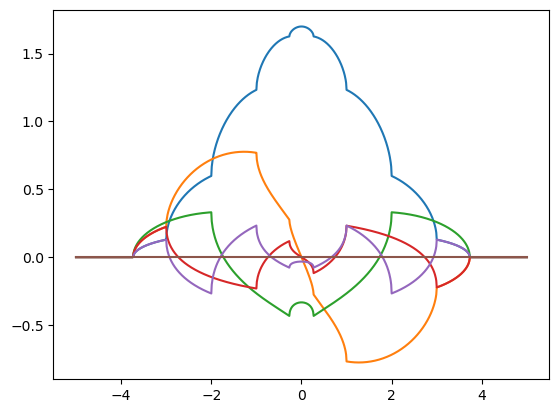

1-element Vector{PyCall.PyObject}:
 PyObject <matplotlib.lines.Line2D object at 0x7f5e8f571310>

In [45]:
ϵs = -5:0.01:5
plt.plot(ϵs,Γ_ij.(ϵs;i=1,j=1,Ny=5))
plt.plot(ϵs,Γ_ij.(ϵs;i=1,j=2,Ny=5))
plt.plot(ϵs,Γ_ij.(ϵs;i=1,j=3,Ny=5))
plt.plot(ϵs,Γ_ij.(ϵs;i=1,j=4,Ny=5))
plt.plot(ϵs,Γ_ij.(ϵs;i=1,j=5,Ny=5))
plt.plot(ϵs,Γ_ij.(ϵs;i=1,j=6,Ny=5))

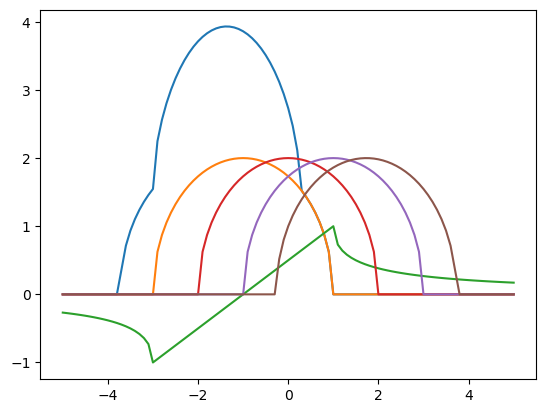

1-element Vector{PyCall.PyObject}:
 PyObject <matplotlib.lines.Line2D object at 0x7f5e8feef230>

In [30]:
Γ(ϵ,n) = -2imag(gr_n(ϵ,n=n))
Λ(ϵ,n) = real(gr_n(ϵ,n=n))

ϵs = -5:0.1:5

plt.plot(ϵs,Γ.(ϵs,1) + Γ.(ϵs,2))
plt.plot(ϵs,Γ.(ϵs,2))
plt.plot(ϵs,Λ.(ϵs,2))
plt.plot(ϵs,Γ.(ϵs,3))
plt.plot(ϵs,Γ.(ϵs,4))
plt.plot(ϵs,Γ.(ϵs,5))

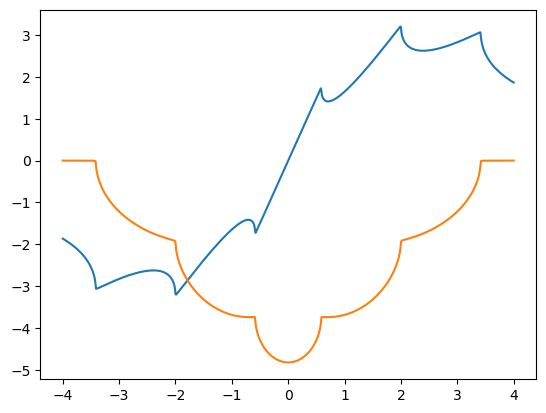

1-element Vector{PyCall.PyObject}:
 PyObject <matplotlib.lines.Line2D object at 0x7f5e9034c1d0>

In [16]:
γ,γso,Bz,ny,nx = 1,0,0,3,3
H0,T =  Block_H(γ,γso,Bz,ny)
S1(E)=real(tr(Σ_LS(E;H0l=H0,H1l=T,Hlc=T,η=1e-3, err=1e-10)))
S2(E)=imag(tr(Σ_LS(E;H0l=H0,H1l=T,Hlc=T,η=1e-3, err=1e-10)))
Es=-4:0.01:4
plt.plot(Es,S1.(Es))
plt.plot(Es,S2.(Es))